# Support Vector Machine


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import load_iris

In [6]:
iris = load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [7]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [15]:
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [24]:
type(iris_df.target[0])

numpy.int64

In [ ]:
iris_df["target"] = iris.target
iris_df["target_class"] = iris_df.target.apply(lambda x: iris.target_names[x])
print(iris_df[iris_df.target == 0].head())
print(iris_df[iris_df.target == 1].head())
print(iris_df[iris_df.target == 2].head())
iris_df.head()

   sepal length (cm)  sepal width (cm)  ...  target  target_class
0                5.1               3.5  ...       0        setosa
1                4.9               3.0  ...       0        setosa
2                4.7               3.2  ...       0        setosa
3                4.6               3.1  ...       0        setosa
4                5.0               3.6  ...       0        setosa

[5 rows x 6 columns]
    sepal length (cm)  sepal width (cm)  ...  target  target_class
50                7.0               3.2  ...       1    versicolor
51                6.4               3.2  ...       1    versicolor
52                6.9               3.1  ...       1    versicolor
53                5.5               2.3  ...       1    versicolor
54                6.5               2.8  ...       1    versicolor

[5 rows x 6 columns]
     sepal length (cm)  sepal width (cm)  ...  target  target_class
100                6.3               3.3  ...       2     virginica
101                5.8

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_class
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [ ]:
iris_df0 = iris_df[iris_df["target"] == 0]
iris_df1 = iris_df[iris_df["target"] == 1]
iris_df2 = iris_df[iris_df["target"] == 2]

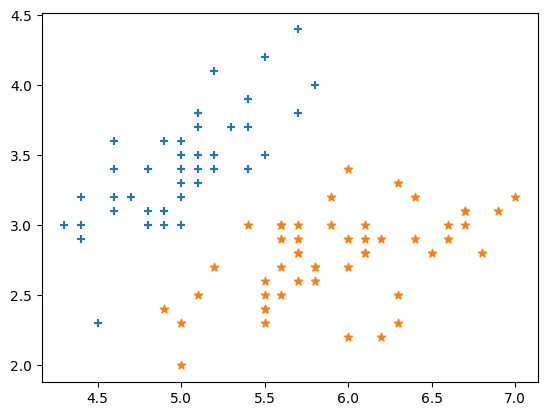

In [ ]:
plt.scatter(iris_df0["sepal length (cm)"], iris_df0["sepal width (cm)"], marker="+")
plt.scatter(iris_df1["sepal length (cm)"], iris_df1["sepal width (cm)"], marker="*")

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

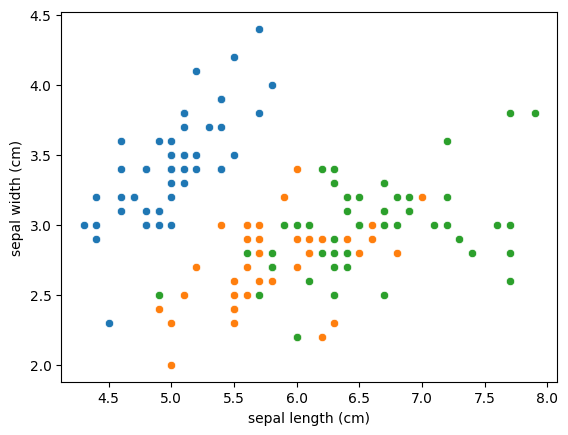

In [ ]:
sns.scatterplot(
    iris_df0,
    x=iris_df0["sepal length (cm)"],
    y=iris_df0["sepal width (cm)"],
    markers="+",
)
sns.scatterplot(
    iris_df1,
    x=iris_df1["sepal length (cm)"],
    y=iris_df1["sepal width (cm)"],
    markers="*",
)
sns.scatterplot(
    iris_df2,
    x=iris_df2["sepal length (cm)"],
    y=iris_df2["sepal width (cm)"],
    markers="*",
)

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

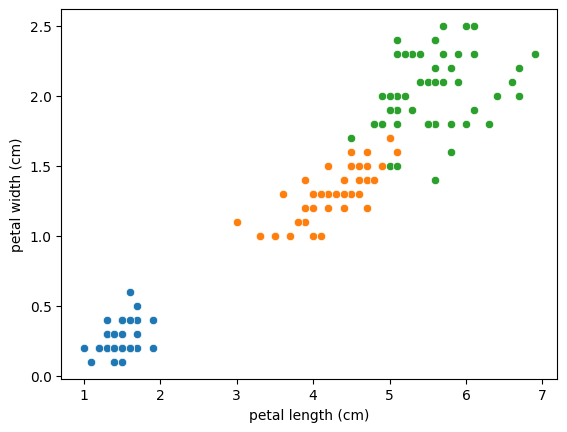

In [ ]:
sns.scatterplot(
    iris_df0,
    x=iris_df0["petal length (cm)"],
    y=iris_df0["petal width (cm)"],
    markers="+",
)
sns.scatterplot(
    iris_df1,
    x=iris_df1["petal length (cm)"],
    y=iris_df1["petal width (cm)"],
    markers="*",
)
sns.scatterplot(
    iris_df2,
    x=iris_df2["petal length (cm)"],
    y=iris_df2["petal width (cm)"],
    markers="*",
)

### Train the model for Iris dataset


In [75]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_class
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [77]:
X = iris_df.drop(["target", "target_class"], axis="columns")
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [79]:
y = iris_df.target
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [103]:
iris_model = SVC(C=1)
iris_model.fit(X_train, y_train)

SVC(C=1)

In [ ]:
iris_model.score(X_test, y_test)

1.0

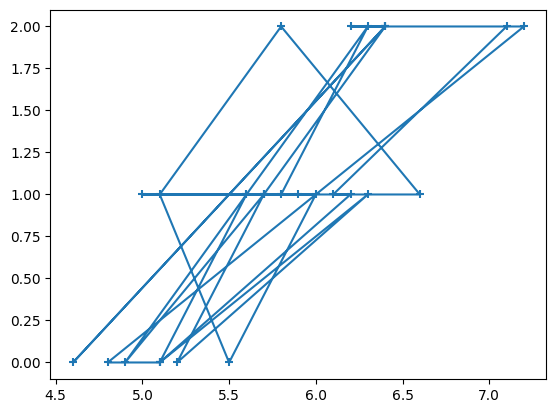

In [113]:
plt.scatter(X_test["sepal length (cm)"], y_test, marker="+")
plt.plot(X_test["sepal length (cm)"], y_test)

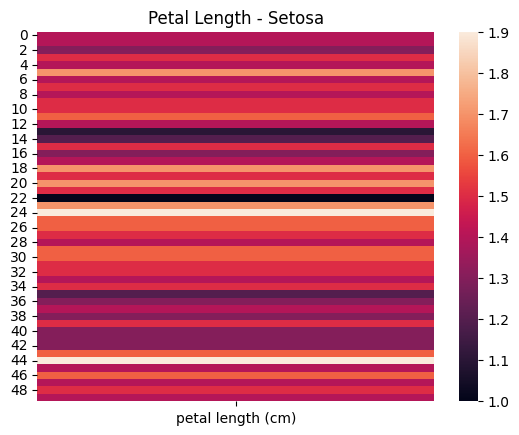

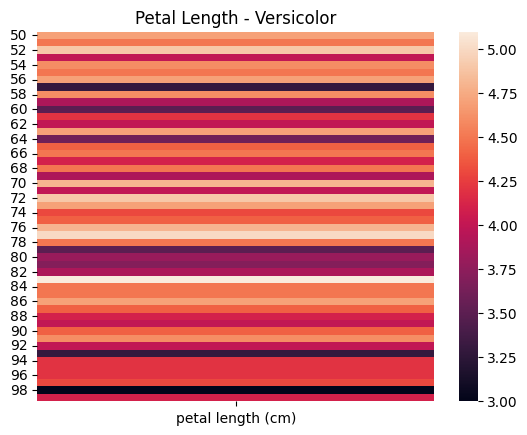

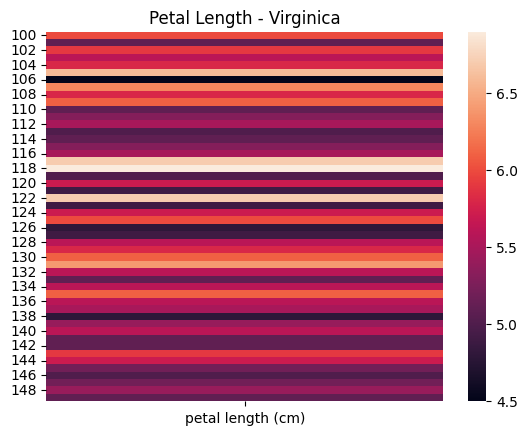

In [127]:

# Plot for Setosa (0–49)
sns.heatmap(X[0:50][['petal length (cm)']])
plt.title("Petal Length - Setosa")
plt.show()

# Plot for Versicolor (50–99)
sns.heatmap(X[50:100][['petal length (cm)']])
plt.title("Petal Length - Versicolor")
plt.show()

# Plot for Virginica (100–149)
sns.heatmap(X[100:150][['petal length (cm)']])
plt.title("Petal Length - Virginica")
plt.show()


## Handwrittern Digits dataset

In [128]:
from sklearn.datasets import load_digits
digit = load_digits()

In [131]:
dir(digit)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [137]:
print(digit.feature_names)
print(digit.data[0])
print(digit.target_names)
print(digit.target[0:20])

['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', 'pixel_6_1', 'pixel_6_2', 'pixel_6_3', 'pixel_6_4', 'pixel_6_5', 'pixel_6_6', 'pixel_6_7', 'pixel_7_0', 'pixel_7_1', 'pixel_7_2', 'pixel_7_3', 'pixel_7_4', 'pixel_7_5', 'pixel_7_6', 'pixel_7_7']
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0. 

In [139]:
print(digit.data.shape)

(1797, 64)


<Figure size 640x480 with 0 Axes>

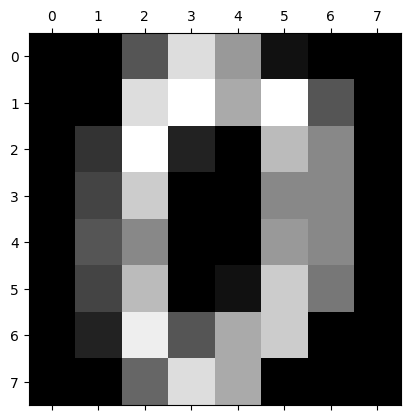

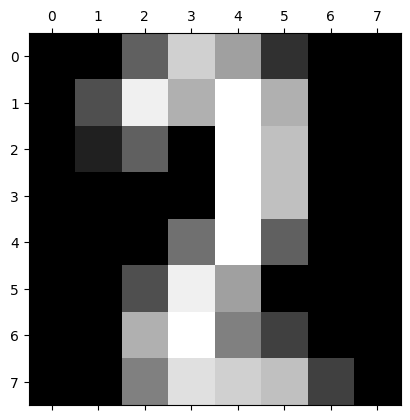

In [156]:
plt.gray()
plt.matshow(digit.images[0])
plt.matshow(digit.images[152])


In [167]:
X_train, X_test, y_train, y_test = train_test_split(digit.data, digit.target, test_size=0.2)

In [316]:
digit_svc_model = SVC(C=6, kernel='rbf')  # best suited C value for this model

In [317]:
digit_svc_model.fit(X_train, y_train)

SVC(C=6)

In [318]:
digit_svc_model.score(X_test,y_test)

0.9916666666666667

In [319]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, digit_svc_model.predict(X_test))

<Axes: >

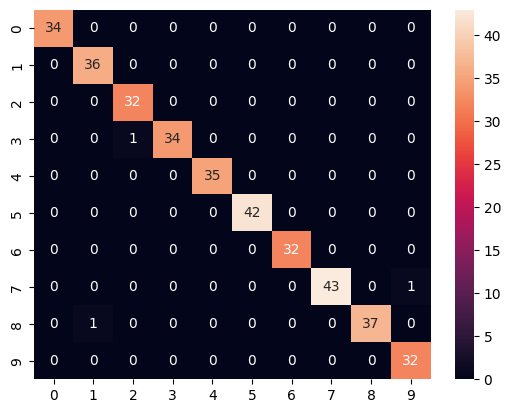

In [320]:
sns.heatmap(cm, annot = True)